In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Загрузка данных

In [2]:
df = pd.read_csv('Data.csv')
print(f"Размер датасета: {df.shape}")
df.head(2)

Размер датасета: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


Обработка пропусков

In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'Пропусков в TotalCharges: {df["TotalCharges"].isnull().sum()}')

Пропусков в TotalCharges: 11


In [4]:
df = df.dropna()
print(f"Размер после удаления пропусков: {df.shape}")

Размер после удаления пропусков: (7032, 21)


Кодирование категориальных признаков

In [5]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Распределение целевой переменной

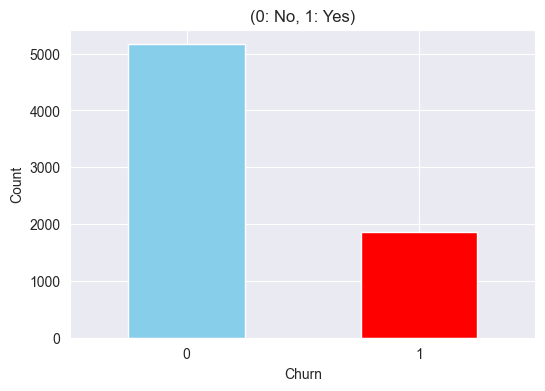

In [6]:
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'red'])
plt.title('(0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Подготовка признаков и целевой переменной

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Обучение модели RF

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

Метрики RF

In [11]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall: {recall_score(y_test, y_pred):.3f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.3f}')

Accuracy: 0.780
Precision: 0.610
Recall: 0.476
F1-Score: 0.535


Обучение XGBoost

In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f'XGBoost - Accuracy: {acc_xgb:.3f}, Precision: {prec_xgb:.3f}, Recall: {rec_xgb:.3f}, F1: {f1_xgb:.3f}, AUC: {auc_xgb:.3f}')

XGBoost - Accuracy: 0.765, Precision: 0.564, Recall: 0.505, F1: 0.533, AUC: 0.804


Подбор гиперпараметров

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая оценка CV:", grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Лучшая оценка CV: 0.8473239036177524


Обучение XGBoost с лучшими параметрами

In [20]:
best_xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric='logloss'
)
best_xgb.fit(X_train, y_train)

y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_proba_best)

print(f'Best XGBoost - Accuracy: {acc_best:.3f}, Precision: {prec_best:.3f}, Recall: {rec_best:.3f}, F1: {f1_best:.3f}, AUC: {auc_best:.3f}')

Best XGBoost - Accuracy: 0.794, Precision: 0.638, Recall: 0.519, F1: 0.572, AUC: 0.838
